# Learned object reconstruction — fixed-catalogue warm-up

This experiment learns ten-band source appearance from compact foundation-feature vectors, using **fixed proposals from the selected standard-loss CenterNet head**. No supplied PSF is used. It is the renderer warm-up: object count and positions do not change yet.

Run these inspection cells freely: they launch no preparation or training. Until the full run exists, this notebook explicitly shows the **untrained, zero-update execution check**. Full-image cached features see the reconstruction targets, so this is ordinary reconstruction, not hidden-pixel prediction.

Method, metric definitions and recovery commands: [decoder/README.md](../decoder/README.md).

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'models/detection2').is_dir())
STUDY = ROOT / 'models/detection2/runs/decoder_warmup_20260915_v1'
CHECK = ROOT / 'models/detection2/runs/decoder_warmup_execution_check_20260915'
PREPARED = STUDY / 'prepared' if (STUDY / 'prepared/metadata.json').exists() else CHECK / 'prepared'
TRAINING = STUDY / 'training' if (STUDY / 'training').exists() else CHECK / 'check'

if TRAINING == CHECK / 'check':
    display(Markdown('**Execution check only — untrained renderer, zero optimizer updates.**'))
print('Study:', STUDY)
print('Inspecting:', TRAINING)
selection = json.loads((ROOT / 'models/detection2/selected_baseline.json').read_text())
print('Frozen detector:', selection['checkpoint'])


**Execution check only — untrained renderer, zero optimizer updates.**

Study: /home/shemmati/Work/Projects/JAISP/models/detection2/runs/decoder_warmup_20260915_v1
Inspecting: /home/shemmati/Work/Projects/JAISP/models/detection2/runs/decoder_warmup_execution_check_20260915/check
Frozen detector: models/detection2/runs/unknown_regions_20260915_v1_12ep/control/final.pt


## Prepared scenes

The full run uses 682 training tiles (16 crops each) and 108 patch-25 validation tiles (8 crops each). The same proposal threshold, >0.15, applies to both splits. Crops may overlap and repeat sources. Counts below describe the actual prepared data, which may still be the small execution check.

In [2]:
meta = json.loads((PREPARED / 'metadata.json').read_text())
print('Full preparation:', meta['complete'])
rows = []
for split, tiles in [('Training', meta['train_tiles']), ('Validation', meta['validation_tiles'])]:
    counts = [n for t in tiles for n in meta['tiles'][t]['objects_per_crop']]
    rows.append({'split': split, 'tiles': len(tiles), 'scenes': len(counts),
                 'mean objects/scene': sum(counts)/max(len(counts), 1), 'maximum objects/scene': max(counts)})
display(pd.DataFrame(rows))
display(pd.DataFrame({'band': meta['bands'], 'crop pixels': meta['band_shapes'],
                      'template pixels': meta['stamp_sizes'], 'arcsec/pixel': meta['pixel_scales_arcsec']}))


Full preparation: False


,split,tiles,scenes,mean objects/scene,maximum objects/scene
0,Training,4,64,13.265625,26
1,Validation,2,16,15.812500,23


,band,crop pixels,template pixels,arcsec/pixel
0,rubin_u,"[64, 64]",25,0.2
1,rubin_g,"[64, 64]",25,0.2
2,rubin_r,"[64, 64]",25,0.2
3,rubin_i,"[64, 64]",25,0.2
4,rubin_z,"[64, 64]",25,0.2
5,rubin_y,"[64, 64]",25,0.2
6,euclid_VIS,"[128, 128]",49,0.1
7,euclid_Y,"[128, 128]",49,0.1
8,euclid_J,"[128, 128]",49,0.1
9,euclid_H,"[128, 128]",49,0.1


## Run status and W&B

The run and focused reconstruction-report links are generated at training startup. Preparation has a separate local progress file and console log.

In [3]:
for path in [STUDY / 'prepared/status.json', TRAINING / 'status.json', TRAINING / 'check.json']:
    if path.exists():
        print(path.name)
        display(json.loads(path.read_text()))
for name, label in [('wandb_run.json', 'W&B run'), ('report.json', 'Reconstruction report')]:
    path = TRAINING / name
    if path.exists():
        record = json.loads(path.read_text())
        if record.get('url'):
            display(Markdown(f"[{label}]({record['url']})"))
    else:
        print(f'{label}: not created yet')


check.json


{'ranks': [{'rank': 0,
   'loss': 1.653080701828003,
   'reconstruction_huber': 1.6530805826187134,
   'gradient_norm': 0.022831859067082405,
   'optimizer_updates': 0,
   'parameters_unchanged': True,
   'scenes': 16,
   'max_objects': 26,
   'real_objects': 192,
   'seconds_per_step': [0.28990311175584793,
    0.04304063320159912,
    0.018540600314736366],
   'peak_memory_gb': 0.467123712},
  {'rank': 1,
   'loss': 2.5022647380828857,
   'reconstruction_huber': 2.5022644996643066,
   'gradient_norm': 0.022831859067082405,
   'optimizer_updates': 0,
   'parameters_unchanged': True,
   'scenes': 16,
   'max_objects': 25,
   'real_objects': 220,
   'seconds_per_step': [0.28702368400990963,
    0.04323515668511391,
    0.01846826821565628],
   'peak_memory_gb': 0.438960128}],
 'optimizer_updates': 0,
 'gradient_norm_spread': 0.0,
 'parameter_count': 462085}

W&B run: not created yet
Reconstruction report: not created yet


## Is the renderer learning useful image structure?

Higher MSE reduction means better reconstruction relative to the training-median image; zero means no improvement. The W&B report also compares against the same model's predicted constant background with objects removed. Lower residual RMSE is better. “Source” apertures are within 1.5 arcsec of fixed proposals, not truth labels. MAD units refer to the training-only scale, 1.4826×MAD.

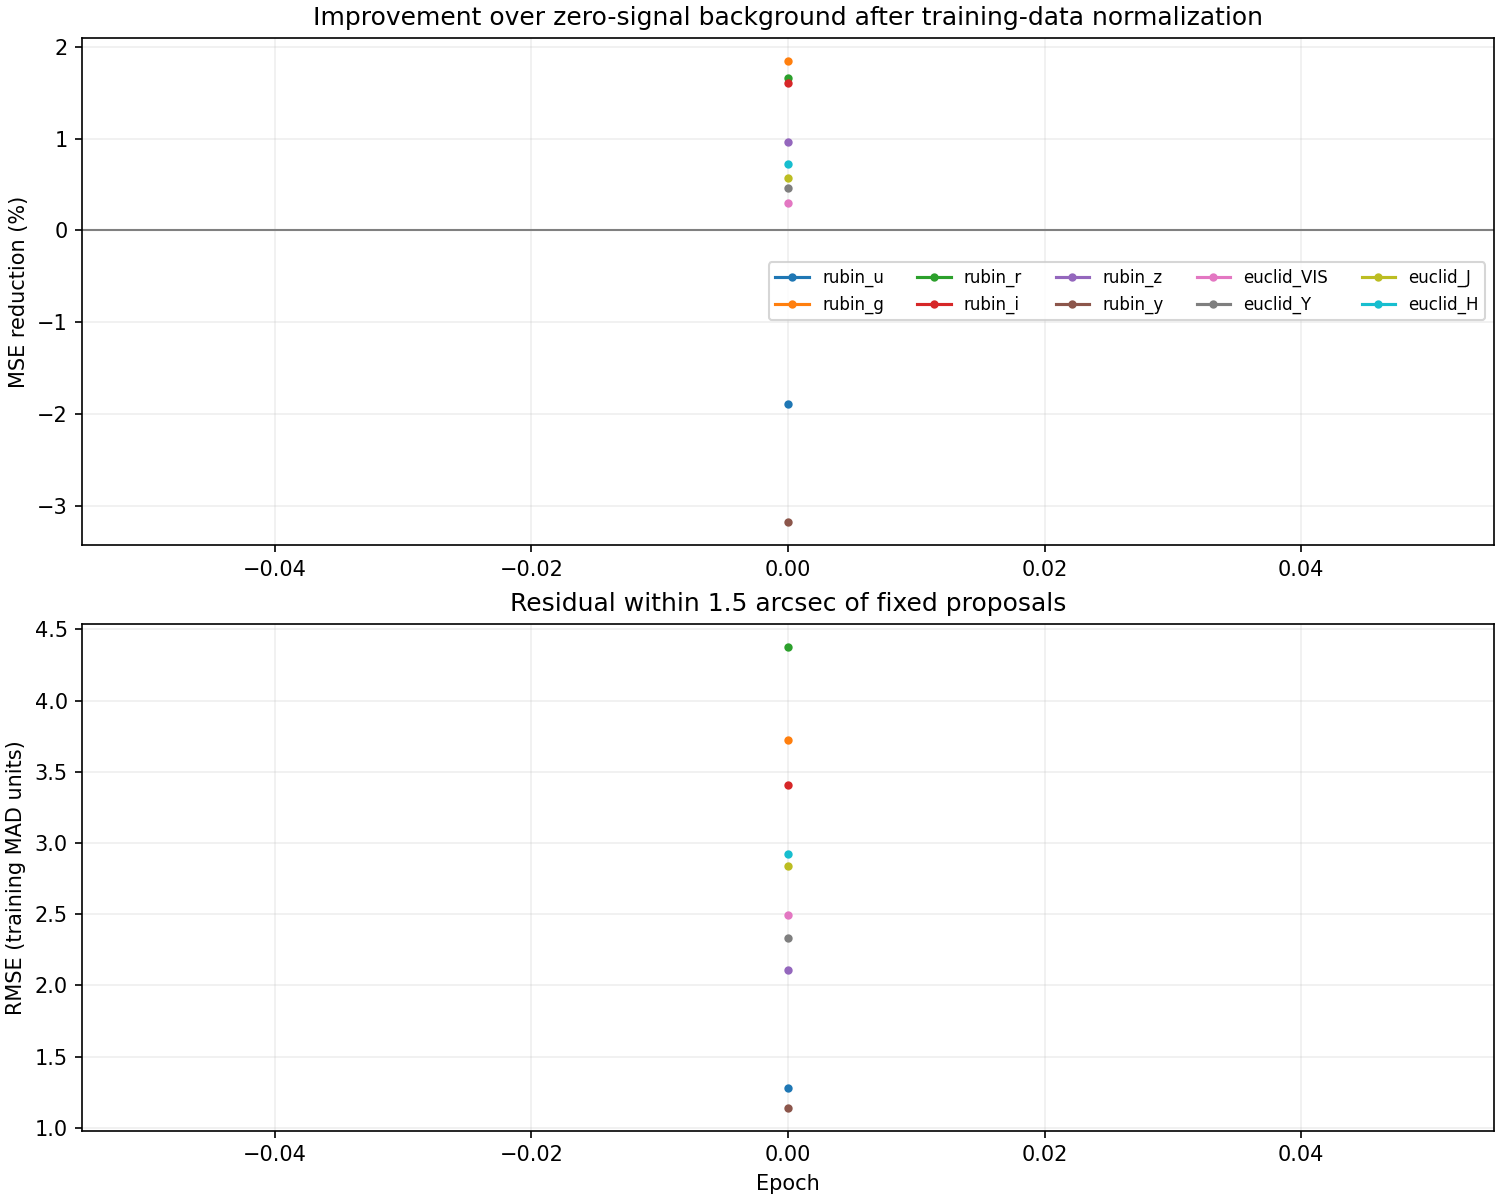

Epoch: 0 | validation scenes: 16


,band,MSE reduction (%),gain beyond learned background (%),source RMSE,background RMSE
0,rubin_u,-1.888656,-1.888656,1.279045,1.205459
1,rubin_g,1.846348,1.846348,3.721344,1.171146
2,rubin_r,1.662980,1.662980,4.378649,1.223151
3,rubin_i,1.600061,1.600061,3.410336,1.101486
4,rubin_z,0.966127,0.966127,2.105453,1.045560
5,rubin_y,-3.172938,-3.172938,1.141139,1.053251
6,euclid_VIS,0.297086,0.297086,2.495727,1.135814
7,euclid_Y,0.462208,0.462208,2.332726,0.931547
8,euclid_J,0.566463,0.566463,2.836416,0.923645
9,euclid_H,0.719228,0.719228,2.922092,0.927911


In [4]:
curve = TRAINING / 'reconstruction_curves.png'
if curve.exists():
    display(Image(filename=str(curve), width=900))
records = sorted(TRAINING.glob('validation_epoch_*.json'))
if records:
    latest = json.loads(records[-1].read_text())['metrics']
    print('Epoch:', latest['epoch'], '| validation scenes:', latest['val/scenes'])
    display(pd.DataFrame([{'band': b,
                          'MSE reduction (%)': latest[f'val/{b}/reconstruction_gain_percent'],
                          'gain beyond learned background (%)': latest[f'val/{b}/gain_over_learned_background_percent'],
                          'source RMSE': latest[f'val/{b}/source_rmse'],
                          'background RMSE': latest[f'val/{b}/background_rmse']}
                         for b in meta['bands']]))
else:
    print('No completed validation yet.')


## Observed, reconstructed and residual images

The same validation scene is shown every epoch with fixed display scales. Magenta crosses mark fixed detector positions. A source left in the residual may indicate a missing proposal, insufficient template support, or poor learned appearance; the image alone does not decide which. The epoch-0 reconstruction is untrained.

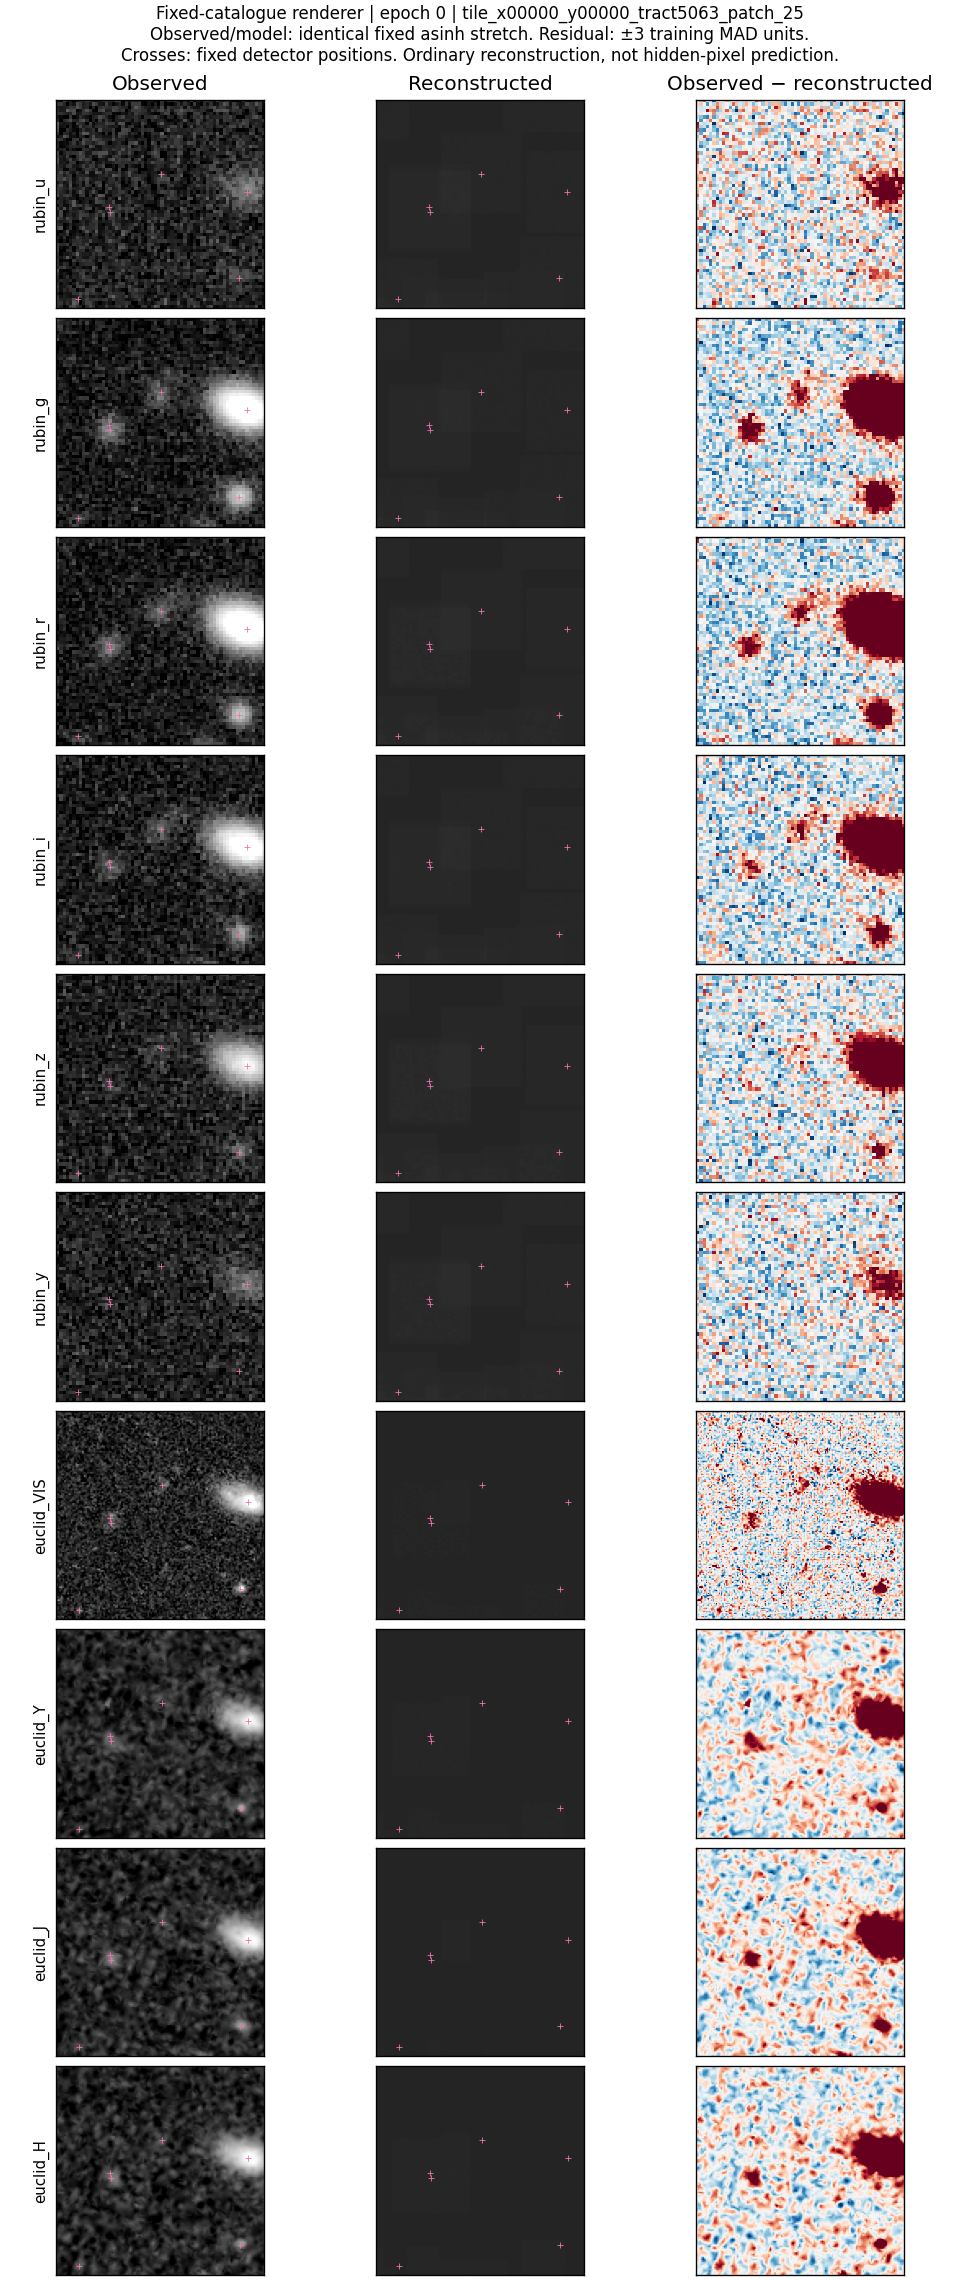

In [5]:
EPOCH = None  # Set to 0, 1, ... to inspect a particular saved epoch.
galleries = sorted(TRAINING.glob('reconstruction_epoch_*.png'))
path = TRAINING / f'reconstruction_epoch_{EPOCH:02d}.png' if EPOCH is not None else (galleries[-1] if galleries else None)
if path is not None and path.exists():
    display(Image(filename=str(path), width=860))
else:
    print('No gallery saved for this epoch yet.')


## Launch from screen

From a terminal, reconnect with `screen -r detection2`. Inside screen press **Ctrl+A, then C** for a new window, and run:

```bash
cd /home/shemmati/Work/Projects/JAISP
bash models/detection2/decoder/run.sh
```

This prepares all crops, then starts **one 20-epoch run using both GPUs**, with online W&B. Detach using **Ctrl+A, then D**. Re-run the inspection cells above to refresh outputs while training runs.

If training is interrupted after preparation completes:

```bash
bash models/detection2/decoder/run.sh --resume
```

Recovery uses the last completed epoch and the same W&B run ID. Full outputs are under `runs/decoder_warmup_20260915_v1/`. The earlier CenterNet comparison remains under its original run folder.